In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib.colors import LogNorm

import glob
import os
import csv
import ast

from scipy.stats import chi2_contingency
from math import sqrt
import calendar

### EA Names mapped  

In [2]:
ea_names_mapped = pd.read_csv('/home/kdonkor_umass_edu/Co-occurrence/ea_names_mapped.csv')

ea_names_mapped = ea_names_mapped[['ea_code9ch', 'LOC_NAME', 'BASE_NAM', 'geometry']]

### EAs n Sites (6km) 

In [3]:
merged_eas_sites = pd.read_csv('/home/kdonkor_umass_edu/Co-occurrence_Rev2/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

In [4]:
filtered_eas_sites_copy = merged_eas_sites

### Global EAs & sites 

In [5]:
sites_eas_df = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__KDee_Project_Git__/Geospatial_Analysis/Hotspot Analysis_Bivariate_Maps_Box_plots/grouped_sites_n_eas_df.csv')

# Safely convert string representations of lists to actual lists
sites_eas_df['site_id'] = sites_eas_df['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
sites_eas_exploded = sites_eas_df.explode('site_id').reset_index(drop=True)

### using 289 EAs 

In [6]:
merged_eas_sites = merged_eas_sites.rename(columns = {'Intersecting_Sites':'site_id'})

# Safely convert string representations of lists to actual lists
merged_eas_sites['site_id'] = merged_eas_sites['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
merged_eas_sites_exploded = merged_eas_sites.explode('site_id').reset_index(drop=True)

In [7]:
# merged_eas_sites_exploded

### --- use the 214 TPLW EAs INSTEAD for uniformity 

In [8]:
tplw_ea_df = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/unique_ea_codes_TPLW.csv')

In [9]:
list_tplw_eas = tplw_ea_df['ea_code9ch'].unique().tolist()

merged_eas_sites_TPLW = merged_eas_sites[ merged_eas_sites['ea_code9ch'].isin(list_tplw_eas) ].reset_index(drop=True)

In [10]:
# Safely convert string representations of lists to actual lists
merged_eas_sites_TPLW['site_id'] = merged_eas_sites_TPLW['site_id'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
merged_eas_sites_TPLW_exploded = merged_eas_sites_TPLW.explode('site_id').reset_index(drop=True)

In [11]:
merged_eas_sites_TPLW_exploded['ea_code9ch'].nunique()

214

## SAIDI Workflow 

### *** read `monthly` SAIDI 

In [12]:
saidi_monthly_df = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/nLine_dashboard_data/KPI_metrics/all_months/SAIDI_Monthly_Site Id - 13_05_2016 to 13_05_2026.csv')

# Copy dataframe
df = saidi_monthly_df.copy()

# -----------------------------------
# Convert Unix timestamp to datetime
# -----------------------------------
df['time'] = pd.to_datetime(df['time'], unit='ms')

# -----------------------------------
# Sort values
# -----------------------------------
df = df.sort_values(['site_id', 'time'])

# -----------------------------------
# Rename columns
# -----------------------------------
df = df.rename(columns={
    'time': 'Date',
}).reset_index(drop=True)

# -----------------------------------
# Add year column
# -----------------------------------
df['Year'] = df['Date'].dt.year

# -----------------------------------
# Filter only 2022 and 2023
# -----------------------------------
df = df[df['Year'].isin([2022, 2023])]

df['SAIDI'] = df['SAIDI'].round(2)

# -----------------------------------
# Optional: reset index again
# -----------------------------------
df = df.reset_index(drop=True).drop(columns = ['est_uncertainty'])

In [13]:
saidi_monthly_df = df.copy()

### Sites within 214 EAs 

In [14]:
site_list = merged_eas_sites_TPLW_exploded['site_id'].unique().tolist()

saidi_monthly_df = saidi_monthly_df[saidi_monthly_df['site_id'].isin(site_list)].reset_index(drop=True)

### Add months 

In [15]:
saidi_month_eas = saidi_monthly_df.merge(merged_eas_sites_TPLW_exploded, on ='site_id')

saidi_month_eas = saidi_month_eas[['Date', 'Year', 'ea_code9ch', 'site_id', 'SAIDI']]

In [16]:
saidi_month_eas.head()

,Date,Year,ea_code9ch,site_id,SAIDI
0,2022-01-01,2022,30410207,1,13.89
1,2022-02-01,2022,30410207,1,22.29
2,2022-03-01,2022,30410207,1,1.28
3,2022-04-01,2022,30410207,1,11.76
4,2022-05-01,2022,30410207,1,14.89


### Horizontal Orientation plot 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import matplotlib.patches as mpatches


def plot_monthly_metric_boxplots(
    df,
    metric_col='SAIDI',
    date_col='Date',
    year_col='Year',
    figsize=(18, 6),
    showfliers=False,

    # Colors by year
    year_colors=None,

    tick_fontsize=12,
    tick_bold=False,

    label_fontsize=18,
    label_bold=True,

    ylabel=None,
    xlabel='Month',
    xlabel_y=0.02,

    legend_fontsize=14,
    legend_loc='upper right',

    save_path=None,
    dpi=300
):

    plot_df = df.copy()
    plot_df[date_col] = pd.to_datetime(plot_df[date_col])

    plot_df['Month_Name'] = plot_df[date_col].dt.strftime('%b')
    month_order = list(calendar.month_abbr[1:])

    plot_df['Month_Name'] = pd.Categorical(
        plot_df['Month_Name'],
        categories=month_order,
        ordered=True
    )

    years = sorted(plot_df[year_col].unique())

    if year_colors is None:
        year_colors = {
            2022: '#3182bd',
            2023: '#e6550d'
        }

    if ylabel is None:
        ylabel = f'Monthly {metric_col}'

    fig, axes = plt.subplots(
        1,
        len(years),
        figsize=figsize,
        sharey=True
    )

    if len(years) == 1:
        axes = [axes]

    for ax, year in zip(axes, years):

        year_df = plot_df[
            plot_df[year_col] == year
        ].sort_values('Month_Name')

        box_color = year_colors.get(year, '#4C72B0')

        sns.boxplot(
            data=year_df,
            x='Month_Name',
            y=metric_col,
            order=month_order,
            showfliers=showfliers,
            color=box_color,
            width=0.7,
            linewidth=1.3,
            ax=ax
        )

        ax.set_title('')
        ax.set_xlabel('')

        if ax == axes[0]:
            ax.set_ylabel(
                ylabel,
                fontsize=label_fontsize,
                fontweight='bold' if label_bold else 'normal',
                labelpad=15
            )
        else:
            ax.set_ylabel('')

        ax.tick_params(
            axis='both',
            labelsize=tick_fontsize
        )

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight(
                'bold' if tick_bold else 'normal'
            )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)

        legend_patch = mpatches.Patch(
            color=box_color,
            label=str(year)
        )

        ax.legend(
            handles=[legend_patch],
            title='',
            fontsize=legend_fontsize,
            frameon=False,
            loc=legend_loc
        )

    fig.supxlabel(
        xlabel,
        fontsize=label_fontsize,
        fontweight='bold' if label_bold else 'normal',
        y=xlabel_y
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

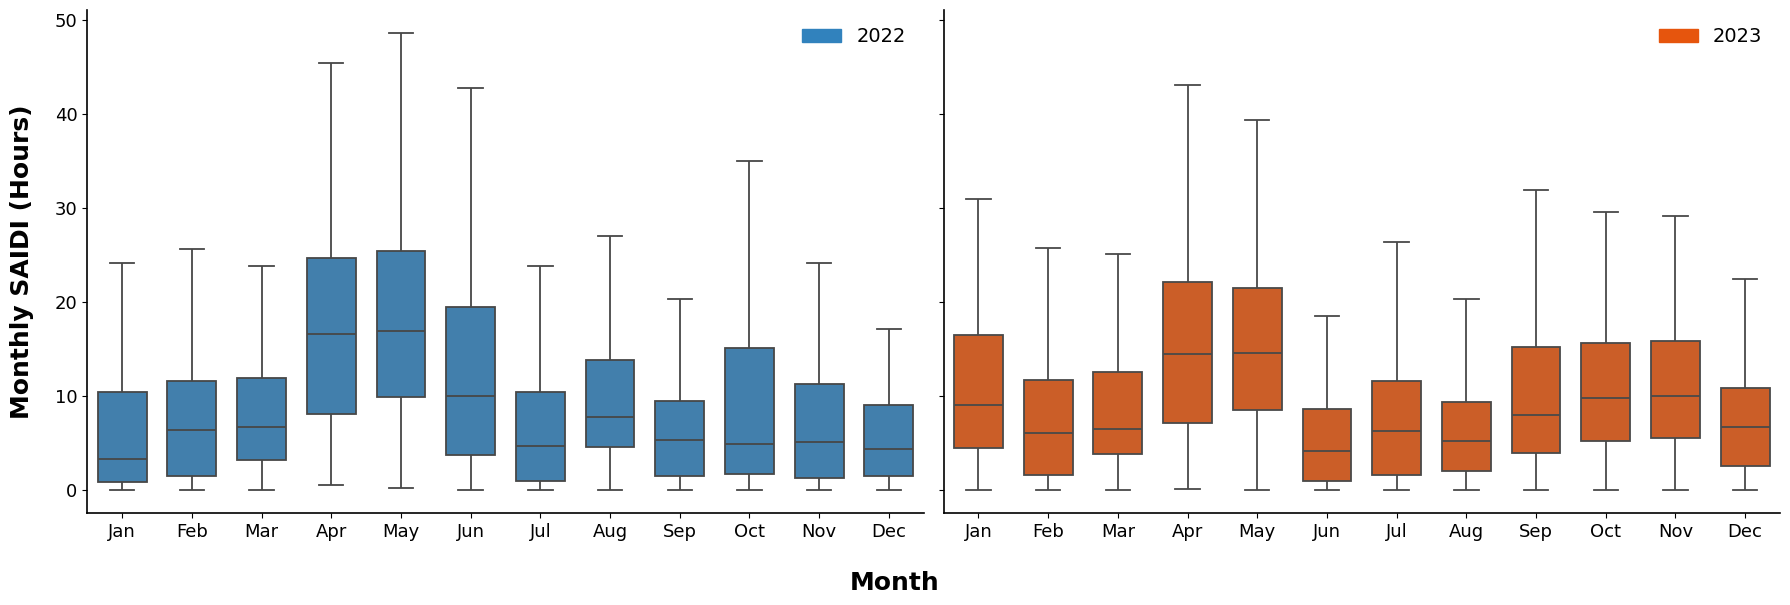

In [18]:
plot_monthly_metric_boxplots(
    saidi_month_eas,
    figsize=(18, 6),
    showfliers=False,
    metric_col='SAIDI',
    ylabel='Monthly SAIDI (Hours)',
    year_colors={
        2022: '#3182bd',
        2023: '#e6550d'
    },
    tick_fontsize = 13,
    tick_bold = False, 
    xlabel_y = 0.00
)

In [19]:
saidi_month_eas

,Date,Year,ea_code9ch,site_id,SAIDI
0,2022-01-01,2022,30410207,1,13.89
1,2022-02-01,2022,30410207,1,22.29
2,2022-03-01,2022,30410207,1,1.28
3,2022-04-01,2022,30410207,1,11.76
4,2022-05-01,2022,30410207,1,14.89
...,...,...,...,...,...
4778,2023-05-01,2023,30404073,473,13.10
4779,2023-06-01,2023,30404073,473,0.35
4780,2023-07-01,2023,30404073,473,6.09
4781,2023-08-01,2023,30404073,473,2.75


### Vertical Orientation plot 

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import matplotlib.patches as mpatches


def plot_monthly_metric_boxplots_vertical(
    df,
    metric_col='SAIDI',
    date_col='Date',
    year_col='Year',

    figsize=(12, 12),
    showfliers=False,

    # Colors by year
    year_colors=None,

    tick_fontsize=12,
    tick_bold=False,

    label_fontsize=18,
    label_bold=True,

    ylabel=None,
    ylabel_x=0.02,

    xlabel='Month',

    legend_fontsize=14,
    legend_loc='upper right',

    hspace=0.15,

    save_path=None,
    dpi=300
):

    plot_df = df.copy()
    plot_df[date_col] = pd.to_datetime(plot_df[date_col])

    plot_df['Month_Name'] = plot_df[date_col].dt.strftime('%b')

    month_order = list(calendar.month_abbr[1:])

    plot_df['Month_Name'] = pd.Categorical(
        plot_df['Month_Name'],
        categories=month_order,
        ordered=True
    )

    years = sorted(plot_df[year_col].unique())

    if year_colors is None:
        year_colors = {
            2022: '#3182bd',
            2023: '#e6550d'
        }

    if ylabel is None:
        ylabel = f'Monthly {metric_col}'

    fig, axes = plt.subplots(
        len(years),
        1,
        figsize=figsize,
        sharex=True,
        sharey=True
    )

    if len(years) == 1:
        axes = [axes]

    for ax, year in zip(axes, years):

        year_df = plot_df[
            plot_df[year_col] == year
        ].sort_values('Month_Name')

        box_color = year_colors.get(year, '#4C72B0')

        sns.boxplot(
            data=year_df,
            x='Month_Name',
            y=metric_col,
            order=month_order,
            showfliers=showfliers,
            color=box_color,
            width=0.7,
            linewidth=1.3,
            ax=ax
        )

        ax.set_ylabel('')

        if ax != axes[-1]:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(
                xlabel,
                fontsize=label_fontsize,
                fontweight='bold' if label_bold else 'normal',
                labelpad=15
            )

        ax.tick_params(
            axis='both',
            labelsize=tick_fontsize
        )

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight(
                'bold' if tick_bold else 'normal'
            )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)

        legend_patch = mpatches.Patch(
            color=box_color,
            label=str(year)
        )

        ax.legend(
            handles=[legend_patch],
            title='',
            fontsize=legend_fontsize,
            frameon=False,
            loc=legend_loc
        )

    fig.supylabel(
        ylabel,
        fontsize=label_fontsize,
        fontweight='bold' if label_bold else 'normal',
        x=ylabel_x
    )

    plt.subplots_adjust(hspace=hspace)

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

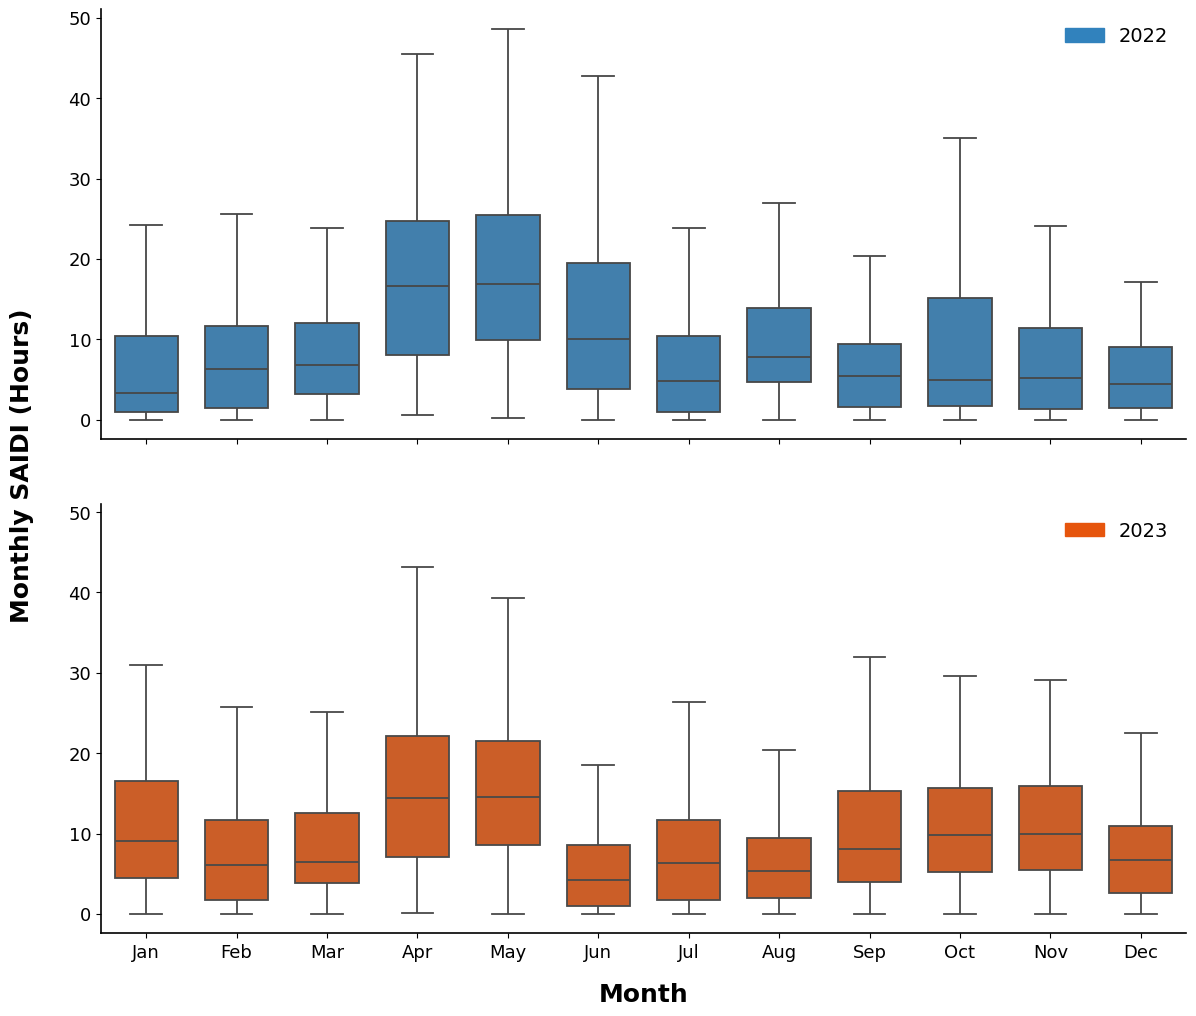

In [21]:
plot_monthly_metric_boxplots_vertical(
    saidi_month_eas,
    metric_col='SAIDI',
    ylabel='Monthly SAIDI (Hours)',
    figsize=(14, 12),
    tick_fontsize=13,
    tick_bold=False,
    ylabel_x=0.06
)

### All years - one plot 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import matplotlib.patches as mpatches


def plot_monthly_metric_boxplots_long(
    df,
    metric_col='SAIDI',
    date_col='Date',
    year_col='Year',
    figsize=(20, 6),
    showfliers=False,

    year_colors=None,

    tick_fontsize=12,
    tick_bold=False,
    label_fontsize=18,
    label_bold=True,

    ylabel=None,
    xlabel='Month-Year',
    xlabel_y=0.00,

    show_every_n_months=2,   # show Jan-22, Mar-22, May-22, etc.
    rotate_xticks=0,

    legend_fontsize=14,
    legend_loc='upper right',

    save_path=None,
    dpi=300
):

    plot_df = df.copy()
    plot_df[date_col] = pd.to_datetime(plot_df[date_col])

    # Sort by actual date
    plot_df = plot_df.sort_values(date_col)

    # Month-Year label: Jan-22, Feb-22, etc.
    plot_df['Month_Year'] = plot_df[date_col].dt.strftime('%b-%y')

    # Preserve chronological order
    month_year_order = (
        plot_df
        .drop_duplicates(date_col)
        .sort_values(date_col)['Month_Year']
        .tolist()
    )

    years = sorted(plot_df[year_col].unique())

    if year_colors is None:
        year_colors = {
            2022: '#3182bd',
            2023: '#e6550d'
        }

    if ylabel is None:
        ylabel = f'Monthly {metric_col}'

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_df,
        x='Month_Year',
        y=metric_col,
        hue=year_col,
        order=month_year_order,
        palette=year_colors,
        showfliers=showfliers,
        width=0.7,
        linewidth=1.3,
        ax=ax
    )

    # -----------------------------
    # X tick labels every n months
    # -----------------------------
    labels = []

    for i, label in enumerate(month_year_order):
        if i % show_every_n_months == 0:
            labels.append(label)
        else:
            labels.append('')

    # Get tick locations
    tick_positions = ax.get_xticks()
    
    # Explicitly set ticks first
    ax.set_xticks(tick_positions)
    
    # Then set labels
    ax.set_xticklabels(
        labels,
        fontsize=tick_fontsize,
        fontweight='bold' if tick_bold else 'normal',
        rotation=rotate_xticks
    )

    # -----------------------------
    # Labels
    # -----------------------------
    ax.set_ylabel(
        ylabel,
        fontsize=label_fontsize,
        fontweight='bold' if label_bold else 'normal',
        labelpad=15
    )

    ax.set_xlabel('')

    fig.supxlabel(
        xlabel,
        fontsize=label_fontsize,
        fontweight='bold' if label_bold else 'normal',
        y=xlabel_y
    )

    ax.tick_params(
        axis='y',
        labelsize=tick_fontsize
    )

    for label in ax.get_yticklabels():
        label.set_fontweight(
            'bold' if tick_bold else 'normal'
        )

    # -----------------------------
    # Spines
    # -----------------------------
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # -----------------------------
    # Legend
    # -----------------------------
    handles = [
        mpatches.Patch(
            color=year_colors.get(year, '#4C72B0'),
            label=str(year)
        )
        for year in years
    ]

    ax.legend(
        handles=handles,
        title='',
        fontsize=legend_fontsize,
        frameon=False,
        loc=legend_loc
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

In [36]:
# plot_monthly_metric_boxplots_long(
#     saidi_month_eas,
#     figsize=(20, 6),
#     showfliers=False,
#     metric_col='SAIDI',
#     ylabel='Monthly SAIDI (Hours)',
#     year_colors={
#         2022: '#3182bd',
#         2023: '#e6550d'
#     },
#     tick_fontsize=13,
#     tick_bold=False,
#     xlabel_y=0.00,
#     show_every_n_months=2
# )

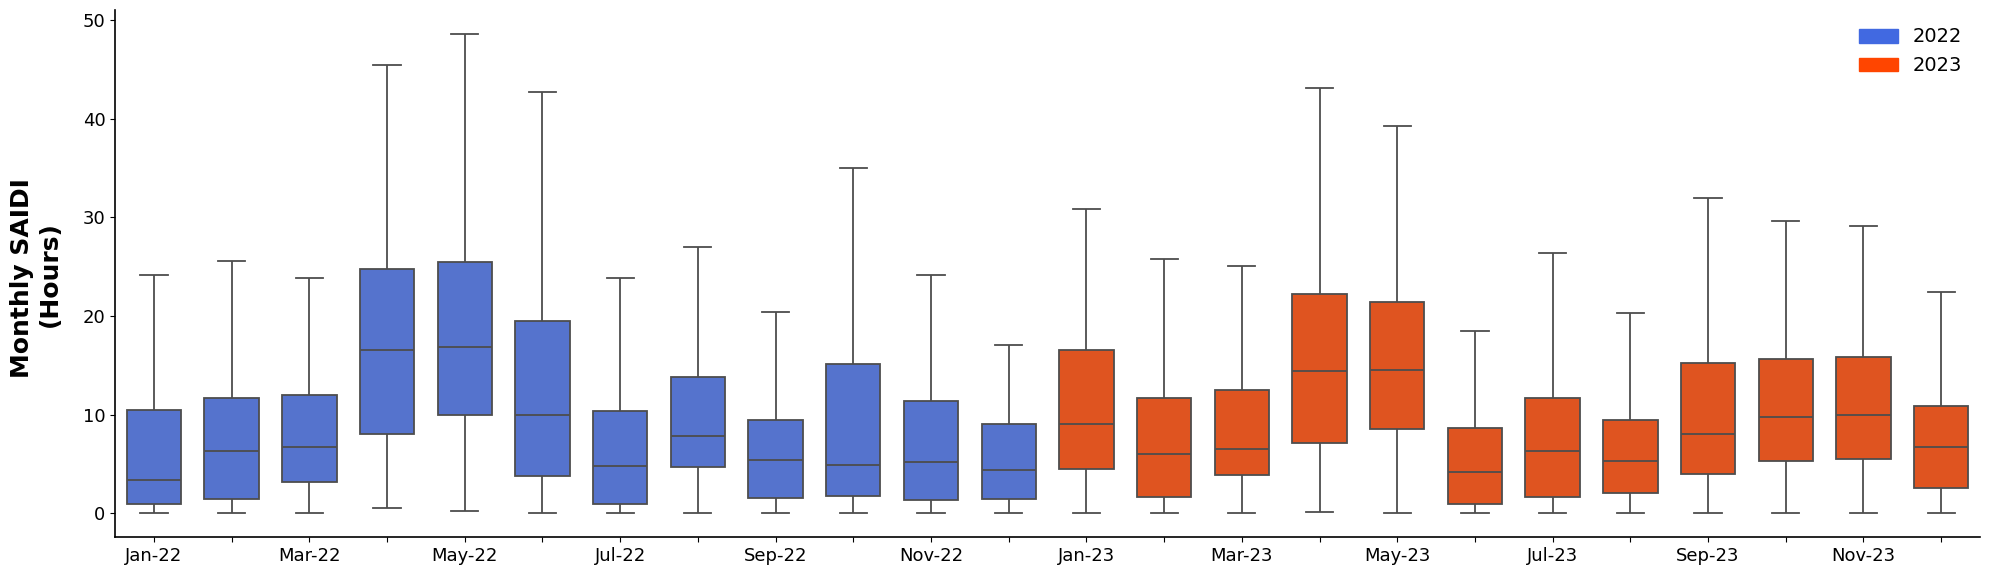

In [37]:
plot_monthly_metric_boxplots_long(
    saidi_month_eas,
    figsize=(20, 6),
    showfliers=False,
    metric_col='SAIDI',
    ylabel='Monthly SAIDI \n(Hours)',
    xlabel='',
    year_colors={
        2022: 'royalblue',
        2023: 'orangered'
    },
    tick_fontsize=13,
    tick_bold=False,
    xlabel_y=0.00,
    show_every_n_months=2, 
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/final_plots/monthly_saidi.png'
)

## `SAIFI` Workflow 

### *** read `monthly` SAIFI 

In [25]:
saifi_monthly_df = pd.read_csv(
    '/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/nLine_dashboard_data/KPI_metrics/all_months/SAIFI_Monthly_Site Id - 13_05_2016 to 13_05_2026.csv'
)

# Copy dataframe
df = saifi_monthly_df.copy()

# -----------------------------------
# Convert Unix timestamp to datetime
# -----------------------------------
df['time'] = pd.to_datetime(df['time'], unit='ms')

# -----------------------------------
# Sort values
# -----------------------------------
df = df.sort_values(['site_id', 'time'])

# -----------------------------------
# Rename columns
# -----------------------------------
df = df.rename(columns={
    'time': 'Date',
    'SAIDI': 'SAIFI'
}).reset_index(drop=True)

# -----------------------------------
# Add year column
# -----------------------------------
df['Year'] = df['Date'].dt.year

# -----------------------------------
# Filter only 2022 and 2023
# -----------------------------------
df = df[df['Year'].isin([2022, 2023])]

# -----------------------------------
# Round SAIFI
# -----------------------------------
df['SAIFI'] = df['SAIFI'].round(2)

# -----------------------------------
# Final cleanup
# -----------------------------------
df = (
    df.reset_index(drop=True)
      .drop(columns=['est_uncertainty']))

In [26]:
saifi_monthly_df = df.copy()

### Sites within 214 EAs 

In [27]:
saifi_monthly_df = saifi_monthly_df[saifi_monthly_df['site_id'].isin(site_list)].reset_index(drop=True)

### Add months 

In [28]:
saifi_month_eas = saifi_monthly_df.merge(merged_eas_sites_TPLW_exploded, on ='site_id')

saifi_month_eas = saifi_month_eas[['Date', 'Year', 'ea_code9ch', 'site_id', 'SAIFI']]

In [29]:
saifi_month_eas.head()

,Date,Year,ea_code9ch,site_id,SAIFI
0,2022-01-01,2022,30410207,1,7.18
1,2022-02-01,2022,30410207,1,4.90
2,2022-03-01,2022,30410207,1,4.00
3,2022-04-01,2022,30410207,1,12.33
4,2022-05-01,2022,30410207,1,6.44


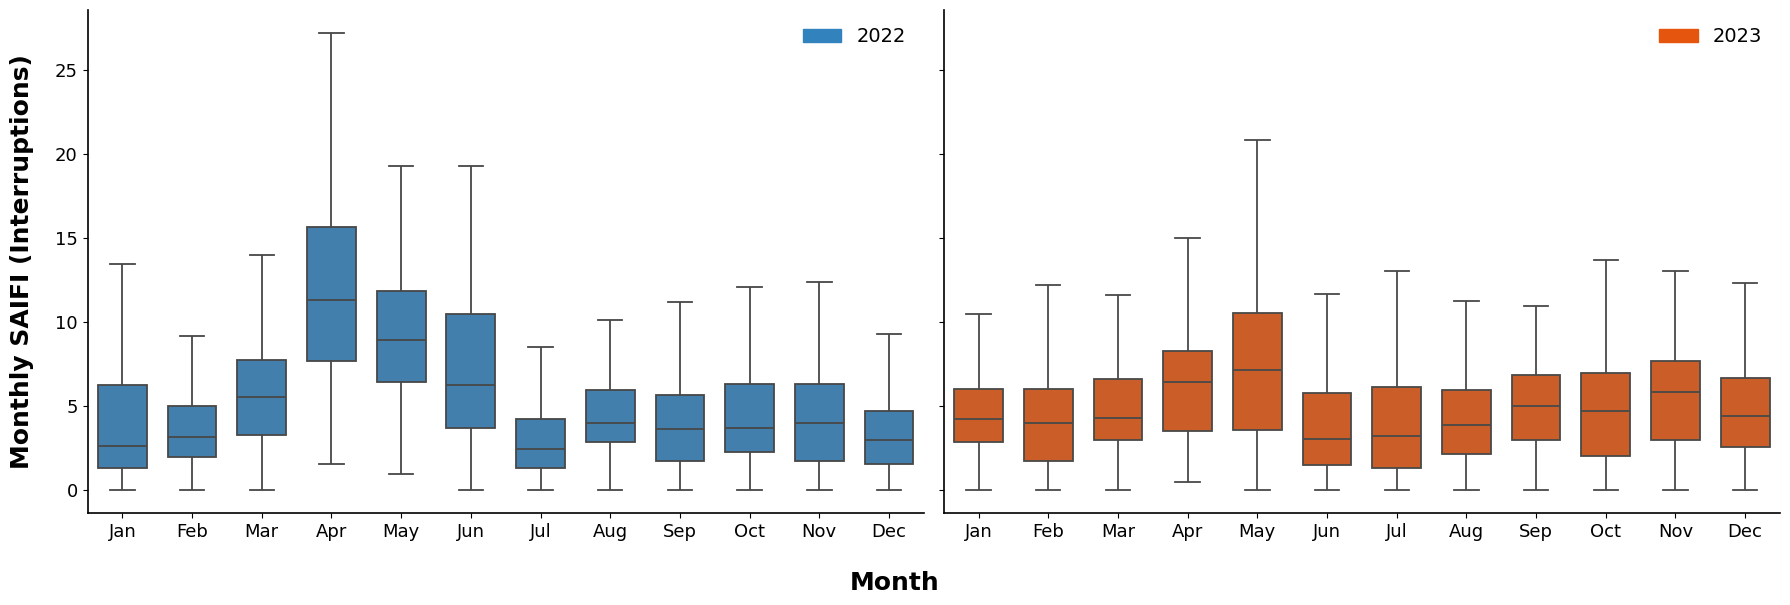

In [30]:
plot_monthly_metric_boxplots(
    saifi_month_eas,
    figsize=(18, 6),
    showfliers=False,
    metric_col='SAIFI',
    ylabel='Monthly SAIFI (Interruptions)',
    year_colors={
        2022: '#3182bd',
        2023: '#e6550d'
    },
    tick_fontsize = 13,
    tick_bold = False, 
    xlabel_y = 0.00
)

In [38]:
# plot_monthly_metric_boxplots_vertical(
#     saifi_month_eas,
#     metric_col='SAIFI',
#     ylabel='Monthly SAIFI (Interruptions)',
#     figsize=(14, 12),
#     tick_fontsize=13,
#     tick_bold=False,
#     ylabel_x=0.06
# )

### All years - one plot - `SAIFI`

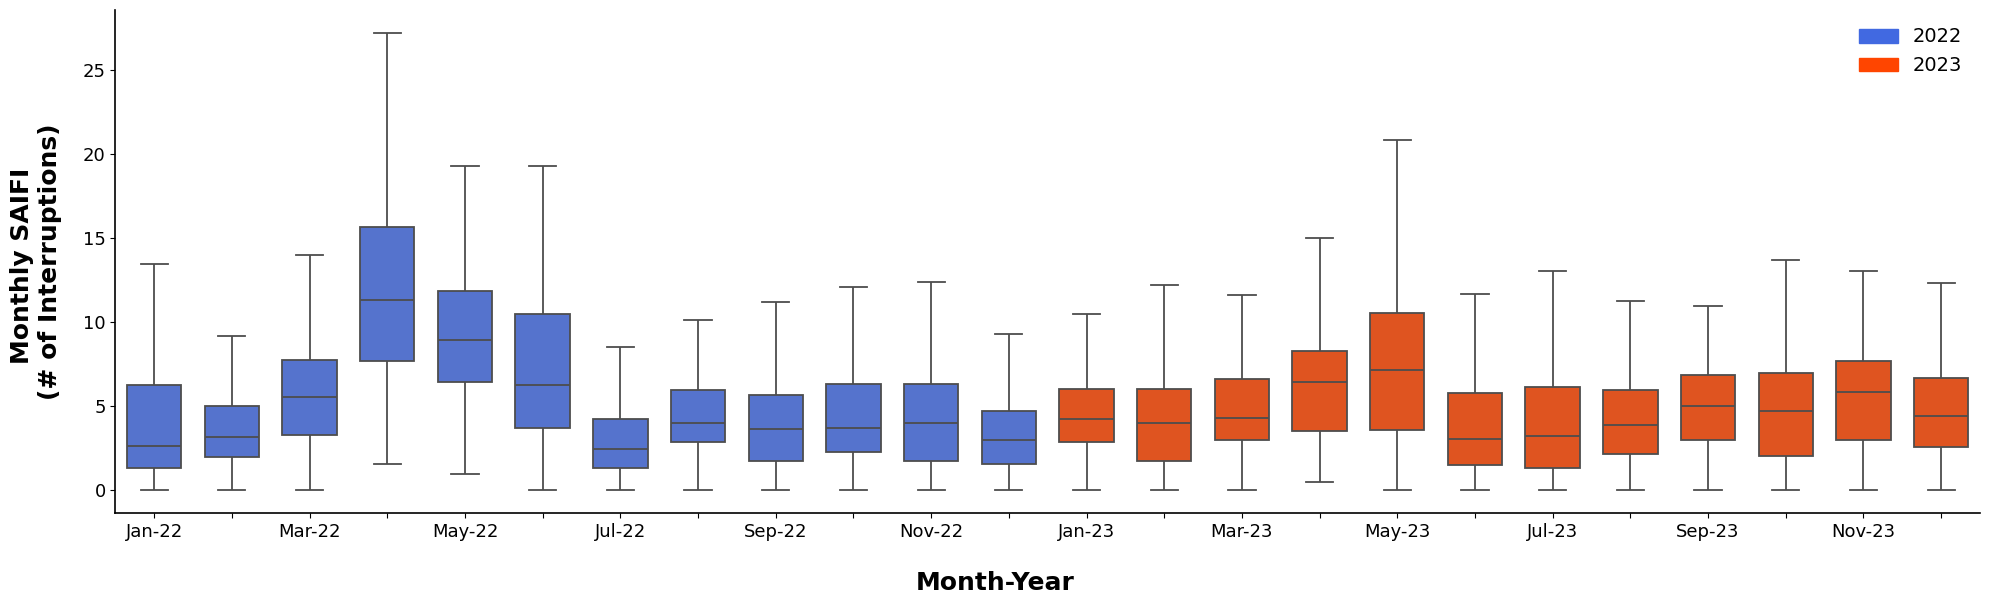

In [39]:
plot_monthly_metric_boxplots_long(
    saifi_month_eas,
    figsize=(20, 6),
    showfliers=False,
    metric_col='SAIFI',
    ylabel='Monthly SAIFI \n(# of Interruptions)',
    year_colors={
        2022: 'royalblue',
        2023: 'orangered'
    },
    tick_fontsize=13,
    tick_bold=False,
    xlabel_y=0.00,
    show_every_n_months=2, 
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/final_plots/monthly_saifi.png'
)

### Vertically stacked 

In [40]:
def plot_monthly_metric_boxplots_stacked(
    df_top,
    df_bottom,
    metric_col_top='SAIDI',
    metric_col_bottom='SAIFI',
    date_col='Date',
    year_col='Year',
    figsize=(20, 12),
    showfliers=False,
    year_colors=None,
    tick_fontsize=13,
    tick_bold=False,
    label_fontsize=18,
    label_bold=True,
    ylabel_top='Monthly SAIDI\n(Hours)',
    ylabel_bottom='Monthly SAIFI\n(# of Interruptions)',
    xlabel='Month-Year',
    xlabel_y=0.00,
    show_every_n_months=2,
    rotate_xticks=0,
    legend_fontsize=14,
    legend_loc='upper right',
    save_path=None,
    dpi=300
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.patches as mpatches

    if year_colors is None:
        year_colors = {
            2022: 'royalblue',
            2023: 'orangered'
        }

    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=figsize, sharex=False)

    panel_data = [
        (ax_top, df_top, metric_col_top, ylabel_top, 'a'),
        (ax_bottom, df_bottom, metric_col_bottom, ylabel_bottom, 'b')
    ]

    for ax, df, metric_col, ylabel, panel_label in panel_data:

        plot_df = df.copy()
        plot_df[date_col] = pd.to_datetime(plot_df[date_col])
        plot_df = plot_df.sort_values(date_col)
        plot_df['Month_Year'] = plot_df[date_col].dt.strftime('%b-%y')

        month_year_order = (
            plot_df
            .drop_duplicates(date_col)
            .sort_values(date_col)['Month_Year']
            .tolist()
        )

        years = sorted(plot_df[year_col].unique())

        sns.boxplot(
            data=plot_df,
            x='Month_Year',
            y=metric_col,
            hue=year_col,
            order=month_year_order,
            palette=year_colors,
            showfliers=showfliers,
            width=0.7,
            linewidth=1.3,
            ax=ax
        )

        # -----------------------------
        # X tick labels every n months
        # -----------------------------
        labels = []
        for i, label in enumerate(month_year_order):
            if i % show_every_n_months == 0:
                labels.append(label)
            else:
                labels.append('')

        tick_positions = ax.get_xticks()
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(
            labels,
            fontsize=tick_fontsize,
            fontweight='bold' if tick_bold else 'normal',
            rotation=rotate_xticks
        )

        # -----------------------------
        # Labels
        # -----------------------------
        ax.set_ylabel(
            ylabel,
            fontsize=label_fontsize,
            fontweight='bold' if label_bold else 'normal',
            labelpad=15
        )
        ax.set_xlabel('')

        ax.tick_params(axis='y', labelsize=tick_fontsize)
        for label in ax.get_yticklabels():
            label.set_fontweight('bold' if tick_bold else 'normal')

        # -----------------------------
        # Spines
        # -----------------------------
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)

        # -----------------------------
        # Panel label
        # -----------------------------
        ax.text(
            -0.04, 1.02, panel_label,
            transform=ax.transAxes,
            fontsize=label_fontsize,
            fontweight='bold',
            va='bottom'
        )

        # -----------------------------
        # Remove individual legend
        # -----------------------------
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    # -----------------------------
    # Shared x label
    # -----------------------------
    fig.supxlabel(
        xlabel,
        fontsize=label_fontsize,
        fontweight='bold' if label_bold else 'normal',
        y=xlabel_y
    )

    # -----------------------------
    # Shared legend
    # -----------------------------
    handles = [
        mpatches.Patch(
            color=year_colors.get(year, '#4C72B0'),
            label=str(year)
        )
        for year in years
    ]

    fig.legend(
        handles=handles,
        fontsize=legend_fontsize,
        frameon=False,
        loc=legend_loc
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

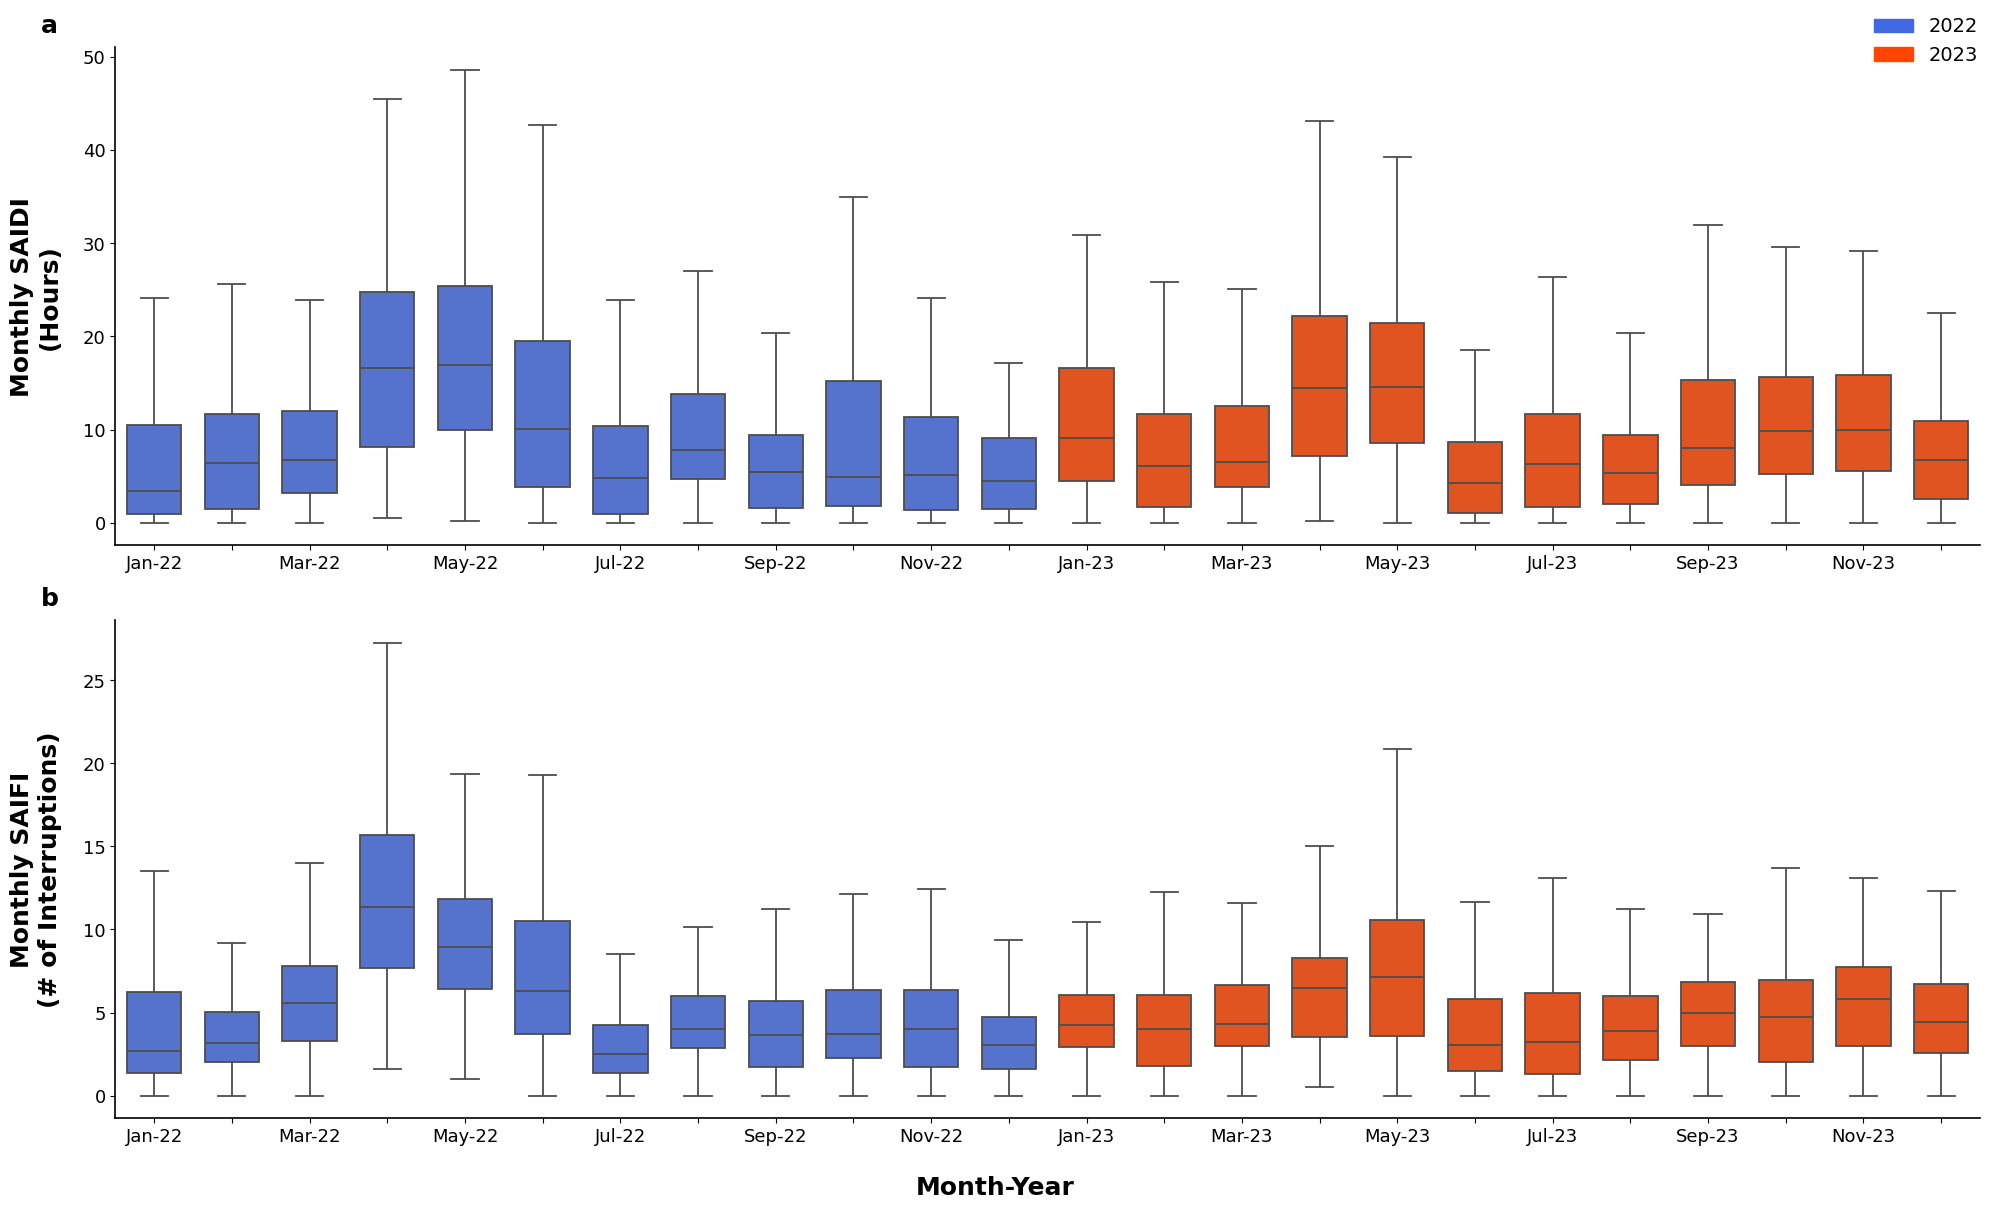

In [42]:

# Usage
plot_monthly_metric_boxplots_stacked(
    df_top=saidi_month_eas,
    df_bottom=saifi_month_eas,
    metric_col_top='SAIDI',
    metric_col_bottom='SAIFI',
    figsize=(20, 12),
    showfliers=False,
    ylabel_top='Monthly SAIDI\n(Hours)',
    ylabel_bottom='Monthly SAIFI\n(# of Interruptions)',
    xlabel='Month-Year',
    year_colors={
        2022: 'royalblue',
        2023: 'orangered'
    },
    tick_fontsize=13,
    tick_bold=False,
    xlabel_y=0.00,
    show_every_n_months=2,
    legend_loc='upper right',
    save_path='/home/kdonkor_umass_edu/Co-occurrence_Rev2/final_plots/monthly_saidi_saifi_stacked.png'
)